#  추천 시스템 - 데이터베이스 저장 및 Text2SQL 실행

---

## 환경 설정 및 준비

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

## ETF 데이터 로드

- ETF 목록: CSV 다운로드 ( http://data.krx.co.kr/contents/MDC/MDI/mdiLoader/index.cmd?menuId=MDC020103010901 )


In [3]:
import pandas as pd
import numpy as np

# ETF 목록
etf_data = pd.read_csv('data/etf_list.csv', encoding='cp949')
etf_data.head()

,종목코드,종목명,상장일,분류체계,운용사,수익률(최근 1년),기초지수,추적오차,순자산총액,괴리율,변동성,복제방법,총보수,과세유형
0,466400,1Q 25-08 회사채(A+이상)액티브,2023/09/19,채권-회사채-단기,하나자산운용,4.52,KIS 2025-08만기형 크레딧 A+이상 지수(총수익),0.11,111916276404,0.03,매우낮음,실물(액티브),0.10,배당소득세(보유기간과세)
1,491610,1Q CD금리액티브(합성),2024/09/24,기타,하나자산운용,0.00,KIS 하나 CD금리 총수익지수,0.05,316206006696,0.02,매우낮음,합성(액티브),0.02,배당소득세(보유기간과세)
2,451060,1Q K200액티브,2023/01/31,주식-시장대표,하나자산운용,-3.66,코스피 200,0.77,99754348820,-0.01,높음,실물(액티브),0.18,배당소득세(보유기간과세)
3,463290,1Q 단기금융채액티브,2023/08/03,채권-혼합-단기,하나자산운용,4.01,MK 머니마켓 지수(총수익),0.05,252717462257,0.00,매우낮음,실물(액티브),0.08,배당소득세(보유기간과세)
4,479080,1Q 머니마켓액티브,2024/04/02,채권-혼합-단기,하나자산운용,0.00,KIS-하나 MMF 지수(총수익),0.06,308255065986,-0.01,매우낮음,실물(액티브),0.05,배당소득세(보유기간과세)


## **Text2SQL** 

- 자연어로 된 질문을 **SQL 쿼리**로 자동 변환

- 데이터베이스 스키마 기반으로 **정확한 쿼리** 생성

- 개발자가 아닌 사용자도 **데이터베이스 검색** 가능

- 데이터베이스 접근성을 높이는 자연어 인터페이스 기술

- 실습 데이터: ETF 목록 데이터 ('`data/etf_list.csv`')


### 1) **SQLite Database**에 저장

- ETF 데이터를 CSV에서 읽어 SQLite **데이터베이스 테이블** 생성

- **데이터 타입** 최적화: 종목코드(INTEGER PRIMARY KEY), 수익률/총보수(FLOAT), 문자열(TEXT)

- 기본 **통계 분석**: 전체 ETF 수, 운용사 수, 평균 수익률/총보수 등 산출

In [6]:
# ETF 목록
etf_data.head(2)

,종목코드,종목명,상장일,분류체계,운용사,수익률_최근1년,기초지수,추적오차,순자산총액,괴리율,변동성,복제방법,총보수,과세유형
0,466400,1Q 25-08 회사채(A+이상)액티브,2023/09/19,채권-회사채-단기,하나자산운용,4.52,KIS 2025-08만기형 크레딧 A+이상 지수(총수익),0.11,111916276404,0.03,매우낮음,실물(액티브),0.10,배당소득세(보유기간과세)
1,491610,1Q CD금리액티브(합성),2024/09/24,기타,하나자산운용,0.00,KIS 하나 CD금리 총수익지수,0.05,316206006696,0.02,매우낮음,합성(액티브),0.02,배당소득세(보유기간과세)


In [4]:
# 열 이름 변경
etf_data.columns = ['종목코드', '종목명', '상장일', '분류체계', '운용사', '수익률_최근1년', '기초지수', '추적오차',
       '순자산총액', '괴리율', '변동성', '복제방법', '총보수', '과세유형']

In [7]:
import pandas as pd

# 데이터 타입 변환
def convert_to_numeric_safely(value):
    try:
        return pd.to_numeric(value)
    except:
        return None

# 각 컬럼의 데이터 타입 변환
etf_data['종목코드'] = etf_data['종목코드'].apply(lambda x: str(x).strip())
etf_data['수익률_최근1년'] = etf_data['수익률_최근1년'].apply(convert_to_numeric_safely)
etf_data['추적오차'] = etf_data['추적오차'].apply(convert_to_numeric_safely)
etf_data['순자산총액'] = etf_data['순자산총액'].apply(convert_to_numeric_safely)
etf_data['괴리율'] = etf_data['괴리율'].apply(convert_to_numeric_safely)
etf_data['총보수'] = etf_data['총보수'].apply(convert_to_numeric_safely)

# 문자열 데이터 정리
string_columns = ['종목명', '상장일', '분류체계', '운용사', '기초지수', '변동성', '복제방법', '과세유형']
for col in string_columns:
    etf_data[col] = etf_data[col].astype(str).apply(lambda x: x.strip())


# 데이터 타입 확인
etf_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   종목코드      930 non-null    object 
 1   종목명       930 non-null    object 
 2   상장일       930 non-null    object 
 3   분류체계      930 non-null    object 
 4   운용사       930 non-null    object 
 5   수익률_최근1년  930 non-null    float64
 6   기초지수      930 non-null    object 
 7   추적오차      930 non-null    float64
 8   순자산총액     930 non-null    int64  
 9   괴리율       930 non-null    float64
 10  변동성       930 non-null    object 
 11  복제방법      930 non-null    object 
 12  총보수       930 non-null    float64
 13  과세유형      930 non-null    object 
dtypes: float64(4), int64(1), object(9)
memory usage: 101.8+ KB


In [8]:
import pandas as pd
import sqlite3

# SQLite 데이터베이스 생성
conn = sqlite3.connect('etf_database.db')
cursor = conn.cursor()

# 테이블 삭제 (if exists)
cursor.execute("DROP TABLE IF EXISTS ETFs")

# 테이블 생성
cursor.execute("""
CREATE TABLE ETFs (
    종목코드 TEXT PRIMARY KEY,
    종목명 TEXT,
    상장일 TEXT,
    분류체계 TEXT,
    운용사 TEXT,
    수익률_최근1년 REAL,
    기초지수 TEXT,
    추적오차 REAL,
    순자산총액 REAL,
    괴리율 REAL,
    변동성 TEXT,
    복제방법 TEXT,
    총보수 REAL,
    과세유형 TEXT
)
""")

# 데이터 삽입
for _, row in etf_data.iterrows():
    try:
        cursor.execute("""
        INSERT INTO ETFs VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            str(row['종목코드']),
            str(row['종목명']),
            str(row['상장일']),
            str(row['분류체계']),
            str(row['운용사']),
            float(row['수익률_최근1년']) if pd.notna(row['수익률_최근1년']) else None,
            str(row['기초지수']),
            float(row['추적오차']) if pd.notna(row['추적오차']) else None,
            float(row['순자산총액']) if pd.notna(row['순자산총액']) else None,
            float(row['괴리율']) if pd.notna(row['괴리율']) else None,
            str(row['변동성']),
            str(row['복제방법']),
            float(row['총보수']) if pd.notna(row['총보수']) else None,
            str(row['과세유형'])
        ))
    except Exception as e:
        print(f"Error inserting row: {row}")
        print(f"Error message: {str(e)}")
        continue

# 변경사항 저장
conn.commit()

# 데이터베이스 상태 확인
cursor.execute("SELECT COUNT(*) FROM ETFs")
etf_count = cursor.fetchone()[0]
print(f"\n=== 데이터베이스 생성 완료 ===")
print(f"ETF 개수: {etf_count}")


=== 데이터베이스 생성 완료 ===
ETF 개수: 930


In [9]:
# 데이터 확인
print("\n=== 데이터 샘플 ===")
cursor.execute("SELECT * FROM ETFs LIMIT 1")
columns = [description[0] for description in cursor.description]
row = cursor.fetchone()
if row:
    for col, val in zip(columns, row):
        print(f"{col}: {val}")


=== 데이터 샘플 ===
종목코드: 466400
종목명: 1Q 25-08 회사채(A+이상)액티브
상장일: 2023/09/19
분류체계: 채권-회사채-단기
운용사: 하나자산운용
수익률_최근1년: 4.52
기초지수: KIS 2025-08만기형 크레딧 A+이상 지수(총수익)
추적오차: 0.11
순자산총액: 111916276404.0
괴리율: 0.03
변동성: 매우낮음
복제방법: 실물(액티브)
총보수: 0.1
과세유형: 배당소득세(보유기간과세)


In [10]:
# 데이터베이스 종료
conn.close()

### 2) **LangChain**에 연동

- **LangChain**과 ETF DB 연동으로 자연어 쿼리 처리 가능

- **GPT**와 **Gemini** 모델을 활용한 SQL 쿼리 자동 생성

- 한국어 응답을 위한 **QA Chain** 구성 및 쿼리 실행 도구 설정

`(1) DB 스키마 확인`
   - 작업의 첫 단계로 테이블 목록 확인 필요
   - 각 테이블의 **구조와 관계** 파악을 위한 스키마 정보 검토

In [11]:
from langchain_community.utilities import SQLDatabase

# SQLite 데이터베이스 연결
db = SQLDatabase.from_uri("sqlite:///etf_database.db")

# 사용 가능한 테이블 목록 출력
tables = db.get_usable_table_names()
print(tables)

['ETFs']


In [12]:
# 테이블 스키마 정보 출력
print(db.get_table_info())


CREATE TABLE "ETFs" (
	"종목코드" TEXT, 
	"종목명" TEXT, 
	"상장일" TEXT, 
	"분류체계" TEXT, 
	"운용사" TEXT, 
	"수익률_최근1년" REAL, 
	"기초지수" TEXT, 
	"추적오차" REAL, 
	"순자산총액" REAL, 
	"괴리율" REAL, 
	"변동성" TEXT, 
	"복제방법" TEXT, 
	"총보수" REAL, 
	"과세유형" TEXT, 
	PRIMARY KEY ("종목코드")
)

/*
3 rows from ETFs table:
종목코드	종목명	상장일	분류체계	운용사	수익률_최근1년	기초지수	추적오차	순자산총액	괴리율	변동성	복제방법	총보수	과세유형
466400	1Q 25-08 회사채(A+이상)액티브	2023/09/19	채권-회사채-단기	하나자산운용	4.52	KIS 2025-08만기형 크레딧 A+이상 지수(총수익)	0.11	111916276404.0	0.03	매우낮음	실물(액티브)	0.1	배당소득세(보유기간과세)
491610	1Q CD금리액티브(합성)	2024/09/24	기타	하나자산운용	0.0	KIS 하나 CD금리 총수익지수	0.05	316206006696.0	0.02	매우낮음	합성(액티브)	0.02	배당소득세(보유기간과세)
451060	1Q K200액티브	2023/01/31	주식-시장대표	하나자산운용	-3.66	코스피 200	0.77	99754348820.0	-0.01	높음	실물(액티브)	0.18	배당소득세(보유기간과세)
*/


In [13]:
# 기본 쿼리 실행
query = "SELECT * FROM ETFs LIMIT 5"
result = db.run(query)
print(result)

[('466400', '1Q 25-08 회사채(A+이상)액티브', '2023/09/19', '채권-회사채-단기', '하나자산운용', 4.52, 'KIS 2025-08만기형 크레딧 A+이상 지수(총수익)', 0.11, 111916276404.0, 0.03, '매우낮음', '실물(액티브)', 0.1, '배당소득세(보유기간과세)'), ('491610', '1Q CD금리액티브(합성)', '2024/09/24', '기타', '하나자산운용', 0.0, 'KIS 하나 CD금리 총수익지수', 0.05, 316206006696.0, 0.02, '매우낮음', '합성(액티브)', 0.02, '배당소득세(보유기간과세)'), ('451060', '1Q K200액티브', '2023/01/31', '주식-시장대표', '하나자산운용', -3.66, '코스피 200', 0.77, 99754348820.0, -0.01, '높음', '실물(액티브)', 0.18, '배당소득세(보유기간과세)'), ('463290', '1Q 단기금융채액티브', '2023/08/03', '채권-혼합-단기', '하나자산운용', 4.01, 'MK 머니마켓 지수(총수익)', 0.05, 252717462257.0, 0.0, '매우낮음', '실물(액티브)', 0.08, '배당소득세(보유기간과세)'), ('479080', '1Q 머니마켓액티브', '2024/04/02', '채권-혼합-단기', '하나자산운용', 0.0, 'KIS-하나 MMF 지수(총수익)', 0.06, 308255065986.0, -0.01, '매우낮음', '실물(액티브)', 0.05, '배당소득세(보유기간과세)')]


`(2) SQL Chain 설정`
- **SQL Chain** 구성을 위한 **GPT**와 **Gemini** 모델 통합 설정
- 정규식을 활용한 **SQL 쿼리 자동 추출** 기능 구현
- 모델 간 **연계 프로세스** 최적화로 쿼리 생성 효율 향상
- AI 모델 기반 SQL 쿼리 자동화 가능

In [14]:
from langchain_openai import ChatOpenAI
from langchain.chains import create_sql_query_chain

# SQL Chain 설정
gpt_llm = ChatOpenAI(model="gpt-4.1-mini")
gpt_sql = create_sql_query_chain(llm=gpt_llm, db=db)

# 쿼리 실행
test_question = "상위 5개 운용사별 ETF 개수는 몇 개인가요?"
gpt_generated_sql = gpt_sql.invoke({'question':test_question})

print(f"Answer (GPT):\n{gpt_generated_sql}")
print("-"*100)

/Users/1113569/my-project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Answer (GPT):
Question: 상위 5개 운용사별 ETF 개수는 몇 개인가요?
SQLQuery: 
SELECT "운용사", COUNT("종목코드") AS "ETF_개수"
FROM "ETFs"
GROUP BY "운용사"
ORDER BY "ETF_개수" DESC
LIMIT 5;
----------------------------------------------------------------------------------------------------


In [28]:
# from langchain_google_genai import ChatGoogleGenerativeAI
# gemini_llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash")
# gemini_sql = create_sql_query_chain(llm=gemini_llm, db=db)
# gemini_generated_sql = gemini_sql.invoke({'question':test_question}, max_retries=3 )
# print(f"Answer (Gemini):\n{gemini_generated_sql}")
# print("-"*100)

## **SQL QA** 

- **SQL 기반 Q&A 시스템**은 구조화된 데이터를 LLM으로 처리하는 특수 사례
    - **자연어 처리**를 통한 SQL 쿼리 자동 변환 구현
    - 데이터베이스에서 **쿼리 실행 및 결과 추출** 
    - 추출된 데이터를 활용한 **자연어 답변 생성**

- **Chain**과 **Agent** 두 가지 구현 방식으로 자연어 질문에 대한 답변 제공

- **LangGraph**를 활용한 반복적 데이터베이스 쿼리 실행 가능

-참조: https://python.langchain.com/docs/tutorials/sql_qa/

### 1) **Chain** 방식

- **단순 실행 흐름**으로 예측 가능한 결과 도출

- **단일 쿼리** 실행만으로 해결 가능한 단순 질의에 최적화

- 명확한 **입력-출력 구조**로 안정적 동작 보장

`(1) State 상태 정의`

- **LangGraph 상태 관리**를 위한 TypedDict 구조 정의

- 입력 **질문**, **쿼리**, **결과**, **답변**의 4가지 핵심 상태 추적

- 상태 데이터의 단계별 전달로 실행 흐름 제어

In [15]:
from typing import TypedDict

# 상태 정보를 저장하는 State 클래스
class State(TypedDict):
    question: str  # 입력 질문
    query: str     # 생성된 쿼리
    result: str    # 쿼리 결과
    answer: str    # 생성된 답변

`(2) 프롬프트 템플릿`

In [29]:
from langchain_core.prompts import ChatPromptTemplate
from typing_extensions import TypedDict, Annotated

# 프롬프트 템플릿 생성
query_prompt_template = ChatPromptTemplate.from_messages([
    ("system", """
    Given an input question, create a syntactically correct {dialect} query to run to help find the answer. 
    Unless the user specifies in his question a specific number of examples they wish to obtain, 
    always limit your query to at most {top_k} results.
      
    You can order the results by a relevant column to return the most interesting examples in the database.
    Never query for all the columns from a specific table, only ask for a the few relevant columns given the question.
    Pay attention to use only the column names that you can see in the schema description. 
    Be careful to not query for columns that do not exist.
      
    Also, pay attention to which column is in which table.
    Only use the following tables:
    {table_info}
    """),
    ("user", """
    Question:
    {input}
    """)
])

# 프롬프트 템플릿 출력
for m in query_prompt_template.messages:
   m.pretty_print()

================================ System Message ================================


    Given an input question, create a syntactically correct {dialect} query to run to help find the answer. 
    Unless the user specifies in his question a specific number of examples they wish to obtain, 
    always limit your query to at most {top_k} results.

    You can order the results by a relevant column to return the most interesting examples in the database.
    Never query for all the columns from a specific table, only ask for a the few relevant columns given the question.
    Pay attention to use only the column names that you can see in the schema description. 
    Be careful to not query for columns that do not exist.

    Also, pay attention to which column is in which table.
    Only use the following tables:
    {table_info}
    
================================ Human Message =================================


    Question:
    {input}
    


In [30]:
# required 입력 필드 확인 (dialect, input, table_info, top_k)
query_prompt_template.input_schema.model_json_schema()

{'properties': {'dialect': {'title': 'Dialect', 'type': 'string'},
  'input': {'title': 'Input', 'type': 'string'},
  'table_info': {'title': 'Table Info', 'type': 'string'},
  'top_k': {'title': 'Top K', 'type': 'string'}},
 'required': ['dialect', 'input', 'table_info', 'top_k'],
 'title': 'PromptInput',
 'type': 'object'}

`(3) SQL 쿼리 생성`

In [31]:
from langchain_openai import ChatOpenAI

# llm 모델 생성
llm = ChatOpenAI(model="gpt-4.1-mini")

In [32]:
from typing import Annotated, TypedDict

class QueryOutput(TypedDict):
    """Generated SQL query."""
    query: Annotated[str, ..., "Syntactically valid SQL query."]


def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "input": state["question"],
        }
    )
    structured_llm = llm.with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)
    return {"query": result["query"]}

In [33]:
# 쿼리 실행
response = write_query({"question": "총보수가 0.1% 이하인 ETF는 무엇인가요?"}) 

response

{'query': 'SELECT 종목코드, 종목명, 총보수 FROM ETFs WHERE 총보수 <= 0.1 ORDER BY 총보수 ASC LIMIT 10;'}

`(4) SQL 쿼리 실행`

In [34]:
from langchain_community.tools import QuerySQLDatabaseTool

def execute_query(state: State):
    """Execute SQL query."""
    execute_query_tool = QuerySQLDatabaseTool(db=db)
    return {"result": execute_query_tool.invoke(state["query"])}

In [35]:
execute_query({"query": response["query"]})

{'result': "[('265690', 'ACE 러시아MSCI(합성)', 0.0), ('495850', 'KODEX 코리아밸류업', 0.008), ('495050', 'RISE 코리아밸류업', 0.008), ('496080', 'TIGER 코리아밸류업', 0.008), ('449180', 'KODEX 미국S&P500(H)', 0.009), ('379800', 'KODEX 미국S&P500TR', 0.009), ('449190', 'KODEX 미국나스닥100(H)', 0.009), ('379810', 'KODEX 미국나스닥100TR', 0.009), ('489250', 'KODEX 미국배당다우존스', 0.009), ('496090', 'KOSEF 코리아밸류업', 0.009)]"}

`(5) RAG 답변 생성`

In [36]:
def generate_answer(state: State):
    """Answer question using retrieved information as context."""
    prompt = (
        "Given the following user question, corresponding SQL query, "
        "and SQL result, answer the user question.\n\n"
        f'Question: {state["question"]}\n'
        f'SQL Query: {state["query"]}\n'
        f'SQL Result: {state["result"]}'
    )
    response = llm.invoke(prompt)
    return {"answer": response.content}

In [ ]:
question = "총보수가 0.1% 이하인 ETF는 무엇인가요?"

query = write_query({"question": question})["query"]  #type: ignore
result = execute_query({"query": query})["result"]    #type: ignore

response = generate_answer({
    "question": question,
    "query": query,
    "result": result,
})   #type: ignore

print(response["question"])
print(response["query"])
print(response["result"])
print(response["answer"])

KeyError: 'question'

`(6) LangGraph 통합`

- langgraph 설치 (pip 또는 uv)

In [38]:
from langgraph.graph import START, StateGraph 

graph_builder = StateGraph(State)

graph_builder.add_node("write_query", write_query)
graph_builder.add_node("execute_query", execute_query)
graph_builder.add_node("generate_answer", generate_answer)

graph_builder.add_edge(START, "write_query")
graph_builder.add_edge("write_query", "execute_query")
graph_builder.add_edge("execute_query", "generate_answer")  
graph = graph_builder.compile()

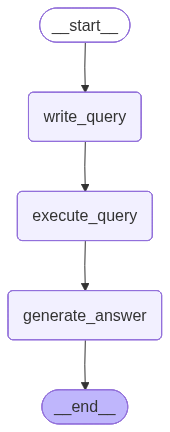

In [39]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [40]:
for step in graph.stream(
    {"question": "총보수가 0.1% 이하인 ETF는 모두 몇 개인가요?"}, stream_mode="updates"
):
    print(step)

{'write_query': {'query': 'SELECT COUNT(*) AS count FROM ETFs WHERE 총보수 <= 0.1;'}}
{'execute_query': {'result': '[(246,)]'}}
{'generate_answer': {'answer': '총보수가 0.1% 이하인 ETF는 모두 246개입니다.'}}


### 2) **Agent** 방식

- **반복 쿼리 실행**으로 복잡한 데이터 분석 가능

- 오류 발생 시 **자동 복구 메커니즘** 작동

- **DB 스키마 기반**의 정확한 답변 생성

- 다단계 추론이 필요한 **복잡한 질의** 처리 가능

`(1) 필요한 도구 준비`

- **ReAct 에이전트**와 **SQLDatabaseToolkit** 통합으로 고급 쿼리 처리
- 다중 쿼리 실행, **오류 복구**, 스키마 기반 응답 기능 제공
- 쿼리 생성, 구문 검사, 테이블 정보 조회 등 **다양한 도구** 활용

In [41]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

tools = toolkit.get_tools()

tools

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x13222a870>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x13222a870>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x13222a870>),
 QuerySQLCheckerTool(description='Use this tool to double check if your 

`(2) 프롬프트 템플릿`

In [42]:
system_message = """
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run, 
then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, 
always limit your query to at most {top_k} results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.
You have access to tools for interacting with the database.
Only use the below tools. Only use the information returned by the below tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

To start you should ALWAYS look at the tables in the database to see what you can query.
Do NOT skip this step.
Then you should query the schema of the most relevant tables.
""".format(dialect=db.dialect, top_k=5)

print(system_message)


You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct sqlite query to run, 
then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, 
always limit your query to at most 5 results.
You can order the results by a relevant column to return the most interesting examples in the database.
Never query for all the columns from a specific table, only ask for the relevant columns given the question.
You have access to tools for interacting with the database.
Only use the below tools. Only use the information returned by the below tools to construct your final answer.
You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

To start you should ALWAYS look at the tables in the database to see what y

`(3) ReAct 에이전트 초기화`

In [44]:
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(llm, tools, prompt=system_message)

`(4) ReAct 에이전트 실행`

In [45]:
from langchain_core.messages import HumanMessage

question = "총보수가 0.1% 이하인 ETF는 모두 몇 개인가요?"

for step in agent_executor.stream(
    {"messages": [HumanMessage(content=question)]}, 
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

총보수가 0.1% 이하인 ETF는 모두 몇 개인가요?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (call_YEM7ufmSOgv5Bl5sb6VVJXaX)
 Call ID: call_YEM7ufmSOgv5Bl5sb6VVJXaX
  Args:
================================= Tool Message =================================
Name: sql_db_list_tables

ETFs
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_GDAj0KWBuvFJYLxcxdugpTnN)
 Call ID: call_GDAj0KWBuvFJYLxcxdugpTnN
  Args:
    table_names: ETFs
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE "ETFs" (
	"종목코드" TEXT, 
	"종목명" TEXT, 
	"상장일" TEXT, 
	"분류체계" TEXT, 
	"운용사" TEXT, 
	"수익률_최근1년" REAL, 
	"기초지수" TEXT, 
	"추적오차" REAL, 
	"순자산총액" REAL, 
	"괴리율" REAL, 
	"변동성" TEXT, 
	"복제방법" TEXT, 
	"총보수" REAL, 
	"과세유형" TEXT, 
	PRIMARY KEY ("종목코드")
)

/*
3 rows fr

## **DB 테이블 관리** 

- **테이블 선택** 및 **다중 테이블 처리** 기능으로 유연한 데이터 관리
- 자연어로 표현된 질문을 **SQL로 자동 변환** 및 실행
- 테이블 관리와 SQL 실행을 통합한 지능형 데이터베이스 시스템 구현

`(1) 특정 테이블만 선택`

- **Sakila Sample Database**
- 출처: https://www.kaggle.com/datasets/atanaskanev/sqlite-sakila-sample-database/data

In [ ]:
from langchain_community.utilities import SQLDatabase

# SQLite 데이터베이스 연결
db = SQLDatabase.from_uri("sqlite:///sqlite-sakila.db", sample_rows_in_table_info=3)

# 데이터베이스 정보 확인
print(db.dialect)
print(db.get_usable_table_names())

In [ ]:
from langchain_community.utilities import SQLDatabase

# ETFs 테이블 제외
simple_db = SQLDatabase.from_uri(
    "sqlite:///sqlite-sakila.db",
    ignore_tables=['actor', 'address', 'category', 'city', 'country', 'customer', 'inventory', 'language', 'payment', 'rental', 'staff', 'store'],
    )
print(simple_db.dialect)

# 사용 가능한 테이블 목록 - ETFs 테이블 제외 확인
print(simple_db.get_usable_table_names())

In [ ]:
films = db.run("SELECT * FROM film LIMIT 5;")

for etf in eval(films):
    print(etf)

`(2) 복잡한 DB 스키마 처리`

- 테이블들을 Film, Customer, Location 3개의 카테고리로 그룹화
- Pydantic 모델을 사용하여 테이블 구조 정의

In [ ]:
# 데이터베이스 정보 확인
print(db.dialect)
print(db.get_usable_table_names())

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from operator import itemgetter
from typing import List

# 테이블 카테고리 정의를 위한 Pydantic 모델
class Table(BaseModel):
    """SQL 데이터베이스의 테이블."""
    name: str = Field(description="SQL 데이터베이스의 테이블 이름")
    category: str = Field(description="테이블이 속하는 카테고리")
    purpose: str = Field(description="테이블의 주요 목적 및 역할")

class TableList(BaseModel):
    """SQL 데이터베이스의 테이블 목록."""
    tables: List[Table] = Field(description="관련된 테이블들의 목록")

# LLM 모델 초기화 
llm = ChatOpenAI(model='gpt-4.1-mini')

# 실제 SQLite Sakila 테이블에 맞춘 시스템 프롬프트
system = """당신은 Sakila DVD 대여점 데이터베이스의 전문가입니다.
사용자 질문과 관련된 SQL 테이블들을 식별하고 적절한 카테고리로 분류하세요.

## 실제 SQLite Sakila 데이터베이스 테이블 구조:
테이블 목록: ['actor', 'address', 'category', 'city', 'country', 'customer', 'film', 'film_actor', 'film_category', 'film_text', 'inventory', 'language', 'payment', 'rental', 'staff', 'store']

### 🎬 Film (영화 및 콘텐츠)
- **film**: 영화 기본 정보 
- **film_category**: 영화-카테고리 관계 테이블 
- **film_actor**: 영화-배우 관계 테이블 
- **category**: 영화 장르/카테고리 
- **language**: 영화 언어 정보 
- **actor**: 배우 정보 

### 👥 Customer (고객 및 직원)
- **customer**: 고객 정보 
- **staff**: 직원 정보 

### 💰 Transaction (거래 및 대여)
- **rental**: 대여 기록 
- **payment**: 결제 정보 

### 📦 Inventory (재고 관리)
- **inventory**: 영화 재고 정보 

### 🏪 Location (위치 및 매장)
- **store**: 매장 정보 
- **address**: 주소 정보 
- **city**: 도시 정보 
- **country**: 국가 정보

## 테이블 간 주요 관계:
- **customer** → **rental** → **payment**: 고객이 영화를 대여하고 결제
- **film** → **inventory** → **rental**: 영화 재고를 통한 대여 관리
- **film** ↔ **actor** (film_actor): 영화와 배우 다대다 관계
- **film** ↔ **category** (film_category): 영화와 장르 다대다 관계
- **store** → **inventory**: 매장별 재고 관리
- **address** → **city** → **country**: 계층적 주소 구조
- **staff** → **store**: 직원과 근무 매장 관계

## 분석 시 고려사항:
- 대여 분석: rental, customer, inventory, film 테이블 조합 필요
- 매출 분석: payment, rental, customer 테이블 조합 필요  
- 영화 검색: film, film_text, actor, category, language 테이블 활용
- 지역별 분석: store, address, city, country 테이블 조합 필요

사용자 질문을 분석하여 관련된 테이블들을 식별하고, 각 테이블의 카테고리와 목적을 명시하세요."""

# 프롬프트 템플릿 생성
prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    ("human", "질문: {input}\n\n위 질문에 답하기 위해 필요한 테이블들을 식별하고 분류해주세요."),
])

# LLM 구조화 출력 설정
structure_llm = llm.with_structured_output(TableList)

# 카테고리 체인 생성
category_chain = prompt | structure_llm 

In [ ]:
# Customer 카테고리 체인 실행 
question = "어떤 고객이 가장 많은 영화를 대여했나요?"
table_list = category_chain.invoke({"input": question})

for table in table_list.tables:
    print(f"📋 테이블: {table.name}")
    print(f"   카테고리: {table.category}")
    print(f"   목적: {table.purpose}")
    print()

In [ ]:
# Film 카테고리 체인 실행
question = "가장 인기 있는 영화 장르는 무엇인가요?"
table_list = category_chain.invoke({"input": question})

for table in table_list.tables:
    print(f"📋 테이블: {table.name}")
    print(f"   카테고리: {table.category}")
    print(f"   목적: {table.purpose}")
    print()

In [ ]:
# Location 카테고리 체인 실행
question = "각 매장의 총 매출은 얼마인가요?"
table_list = category_chain.invoke({"input": question})

for table in table_list.tables:
    print(f"📋 테이블: {table.name}")
    print(f"   카테고리: {table.category}")
    print(f"   목적: {table.purpose}")
    print()


- **모든 테이블 사용**

In [ ]:
from typing import Annotated, TypedDict

class QueryOutput(TypedDict):
    """Generated SQL query."""
    query: Annotated[str, ..., "Syntactically valid SQL query."]

# SQL 쿼리 체인 생성
partial_prompt_template = query_prompt_template.format(
    dialect=db.dialect,
    top_k=10,
    table_info="{table_names_to_use}",
    input="{question}"
)

# 프롬프트 템플릿 생성
prompt = ChatPromptTemplate.from_template(partial_prompt_template)

structured_llm = llm.with_structured_output(QueryOutput)
query_chain = prompt | structured_llm

# SQL 쿼리 생성 - 모든 테이블 사용
response = query_chain.invoke({
    "question": "가장 많은 작품을 대여한 고객은 누구인가요?",
    "table_names_to_use": db.get_table_info()})

print(response.get("query"))


In [ ]:
# SQL 쿼리 실행
db.run(response.get("query"))

- **일부 테이블 사용**

In [ ]:
# 테이블 이름 체인 생성 (테이블 이름 추출)
table_chain = (
    {"input": itemgetter("question")} 
    | category_chain 
    | RunnableLambda(lambda x: [t.name for t in x.tables])
)

# 테이블 이름 체인 실행
table_chain.invoke({"question": "가장 많은 작품을 대여한 고객은 누구인가요?"})

In [ ]:
# 최종 체인 연결 (테이블 이름 추출 -> SQL 쿼리 생성) -> 추출된 일부 테이블 정보를 사용하여 쿼리 생성
full_chain = RunnablePassthrough.assign(
    table_names_to_use=table_chain | RunnableLambda(lambda x: db.get_table_info(x))
    ) | query_chain

response = full_chain.invoke({"question": "가장 많은 작품을 대여한 고객은 누구인가요?"})
print(response.get("query"))

In [ ]:
# SQL 쿼리 실행
db.run(response.get("query")) 

- **Agent로 구현**

In [ ]:
from langchain_core.tools import tool
from typing import List
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import HumanMessage

### 1. 테이블 선택 도구 생성

@tool  
def select_relevant_tables(question: str) -> str:
    """질문과 관련된 테이블의 스키마 정보를 반환한다."""
    # 기존 table_chain 결과를 직접 사용
    try:
        selected_tables = table_chain.invoke({"question": question})
        table_info = db.get_table_info(selected_tables)
        return f"관련 테이블: {', '.join(selected_tables)}\n\n{table_info}"
    except Exception as e:
        return f"테이블 선택 중 오류 발생: {str(e)}"


### 2. Agent 구현

# 기본 SQL 도구킷 생성
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
sql_tools = toolkit.get_tools()

# 커스텀 테이블 선택 도구 추가
custom_tools = [select_relevant_tables]  

# 모든 도구 결합
all_tools = sql_tools + custom_tools

# 4. 시스템 메시지 정의 (테이블 선택 기능 포함)
system_message = f"""
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {db.dialect} query to run, 
then look at the results of the query and return the answer.
Unless the user specifies a specific number of examples they wish to obtain, 
always limit your query to at most 5 results.

You have access to tools for interacting with the database.
Only use the below tools. Only use the information returned by the below tools to construct your final answer.

IMPORTANT WORKFLOW:
1. FIRST, use the 'select_relevant_tables' tool to identify relevant tables for the question
2. THEN, if needed, use 'sql_db_list_tables' to see all available tables
3. THEN, use 'sql_db_schema' to get detailed schema for specific tables
4. THEN, use 'sql_db_query_checker' to validate your query before execution
5. FINALLY, use 'sql_db_query' to execute the validated query

You MUST double check your query before executing it. If you get an error while executing a query, rewrite the query and try again.
DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.

Never query for all the columns from a specific table, only ask for the relevant columns given the question.
"""

# Agent 생성
agent_executor = create_react_agent(llm, all_tools, prompt=system_message)

# 실행
question = "가장 많은 작품을 대여한 고객은 누구인가요?"

for step in agent_executor.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()


In [ ]:
# Film 카테고리 체인 실행
question = "가장 인기 있는 영화 장르는 무엇인가요?"

for step in agent_executor.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

In [ ]:
# Location 카테고리 체인 실행
question = "각 매장의 총 매출은 얼마인가요?"

for step in agent_executor.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()